# Neural-network inversion of the Lyα forest

We will learn the same inverse problem as the direct-FGPA and regularized-MAP notebooks:

\[
d=K\exp\left[-A\Delta_b^2(T_{\rm CAMELS}/10^4\,\mathrm K)^{-0.7}\right]+n
\quad\longrightarrow\quad \Delta_b .
\]

The lesson proceeds from a small **convolutional encoder–decoder** (an autoencoder-shaped supervised inverse) to a **1D U-Net**, then compares both with direct FGPA and regularized MAP on exactly the same held-out mock spectrum.

### Learning goals

Understand tensors, convolutions, activations, pooling, bottlenecks, upsampling, loss, backpropagation, validation, and U-Net skip connections.

### Laptop budget

The demonstration uses 3,328 training skewers and runs explicitly on CPU. Both neural architectures are compact. A classical autoencoder reproduces its input without labels; our first model has that compress–expand shape but is supervised with paired flux and density, so “encoder–decoder” is the precise name.

## 1. CPU-only setup

After creating the course environment, install the CPU wheel once:

    conda activate camels-hands-on
    python -m pip install -r requirements-pytorch-cpu.txt

The first code cell also contains the user-adjustable observation controls. Change `signal_to_noise` and `instrument_fwhm_kms` there before running all cells.

In [1]:
from pathlib import Path
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.optimize import brentq, least_squares
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(7)
torch.manual_seed(7)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
device = torch.device("cpu")  # never auto-select a GPU

data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

# === User-adjustable mock-observation settings ===
signal_to_noise = 5.0         # S/N per native flux pixel
instrument_fwhm_kms = 120.0  # Gaussian instrumental FWHM [km/s]
noise_seed = 2026

# === Assumed thermal relation used only by traditional inversion baselines ===
inversion_T0_K = 10_000.0
inversion_gamma = 1.5

print(f"PyTorch {torch.__version__}; device={device}; threads={torch.get_num_threads()}")
print(f"CUDA was compiled into this wheel: {torch.version.cuda is not None}")

PyTorch 2.13.0+cpu; device=cpu; threads=4
CUDA was compiled into this wheel: False


## 2. Physical forward model and a one-box holdout

We predict \(s=\ln\Delta_b\), which reduces dynamic range and returns positive density after exponentiation. The dataset contains 27 simulation boxes: all 26 boxes numbered 1–26 contribute training examples, while box 0 is reserved as the single untouched final-test box. Within the 26 development boxes, disjoint transverse coordinates provide training and validation skewers. The validation split measures skewer-level generalization; only the final box-0 result measures generalization to a new simulation realization.

The physical constants, central test skewer, instrument, S/N, and random test noise match the MAP notebook.

In [2]:
gas_boxes = np.load(data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy", mmap_mode="r")
dm_boxes = np.load(data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy", mmap_mode="r")
temperature_boxes = np.load(data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy", mmap_mode="r")
N = gas_boxes.shape[1]
box_size, redshift = 25.0, 2.0
dx = box_size / N
x = (np.arange(N) + 0.5) * dx

gas_means = np.array([gas_boxes[i].mean(dtype=np.float64) for i in range(gas_boxes.shape[0])])
test_simulation = 0
training_simulations = np.arange(1, gas_boxes.shape[0])
assert len(training_simulations) == 26
Delta_b_true = gas_boxes[test_simulation, :, 64, 64].astype(np.float64) / gas_means[test_simulation]
dm_means = np.array([dm_boxes[i].mean(dtype=np.float64) for i in range(dm_boxes.shape[0])])
Delta_dm_true = dm_boxes[test_simulation, :, 64, 64].astype(np.float64) / dm_means[test_simulation]
temperature_true = temperature_boxes[test_simulation, :, 64, 64].astype(np.float64)

temperature_reference = 10_000.0  # K; normalization only
inversion_beta = 2.0 - 0.7 * (inversion_gamma - 1.0)
inversion_temperature_normalization = (inversion_T0_K/temperature_reference) ** (-0.7)
target_mean_flux = 0.82
calibration_density = np.concatenate([
    gas_boxes[sim, :, 64, 64].astype(np.float64) / gas_means[sim]
    for sim in training_simulations
])
calibration_temperature = np.concatenate([
    temperature_boxes[sim, :, 64, 64].astype(np.float64)
    for sim in training_simulations
])
calibration_opacity_shape = calibration_density**2 * (calibration_temperature/temperature_reference)**(-0.7)
A_fgpa = brentq(
    lambda A: np.mean(np.exp(-A * calibration_opacity_shape)) - target_mean_flux,
    1e-6, 100.0,
)

velocity_pixel_width = cosmo.H(redshift).to_value(u.km/u.s/u.Mpc) * (dx/cosmo.h) / (1+redshift)
sigma_pixels = instrument_fwhm_kms / (2*np.sqrt(2*np.log(2))) / velocity_pixel_width
K = ndimage.gaussian_filter1d(np.eye(N), sigma_pixels, axis=0, mode="reflect")
noise_sigma = 1/signal_to_noise
density_limits = (0.03, 20.0)

print(f"cube={gas_boxes.shape}, training boxes={len(training_simulations)}, test box={test_simulation}")
print(f"skewer={N}, A={A_fgpa:.5f}; opacity uses actual CAMELS temperature")
print(f"Traditional inversions assume T0={inversion_T0_K:.0f} K, gamma={inversion_gamma:.2f}, beta={inversion_beta:.3f}")
print(f"instrument FWHM={instrument_fwhm_kms:.1f} km/s ({sigma_pixels:.2f} sigma pixels)")
print(f"S/N={signal_to_noise:.1f} per native pixel; flux noise={noise_sigma:.4f}")

cube=(27, 128, 128, 128), training boxes=26, test box=0
skewer=128, A=0.44503; opacity uses actual CAMELS temperature
Traditional inversions assume T0=10000 K, gamma=1.50, beta=1.650
instrument FWHM=120.0 km/s (2.60 sigma pixels)
S/N=5.0 per native pixel; flux noise=0.2000


## 3. Generate paired examples

For each of the 26 training boxes we draw 128 training skewers and 16 validation skewers at non-overlapping \(y,z\) coordinates. At every coordinate we store the baryonic density, co-spatial dark-matter density, and actual CAMELS temperature. The density and temperature jointly generate the FGPA flux before instrumental broadening and Gaussian noise; no imposed temperature–density equation of state is used. The aligned DM skewer is retained for the later direct-DM target. Density is limited to the broad MAP bounds because fully saturated cells cannot be uniquely recovered from flux.

In [3]:
def draw_disjoint_skewers(simulations, train_per_box, val_per_box, rng):
    train_baryon, validation_baryon = [], []
    train_dm, validation_dm = [], []
    train_temperature, validation_temperature = [], []
    for sim in simulations:
        # Unique transverse coordinates make the two skewer sets disjoint.
        flat = rng.choice(N*N, train_per_box + val_per_box, replace=False)
        for baryon_destination, dm_destination, temperature_destination, coordinates in (
            (train_baryon, train_dm, train_temperature, flat[:train_per_box]),
            (validation_baryon, validation_dm, validation_temperature, flat[train_per_box:]),
        ):
            for coordinate in coordinates:
                y, z = divmod(int(coordinate), N)
                Delta_b = gas_boxes[sim, :, y, z].astype(np.float64) / gas_means[sim]
                Delta_dm = dm_boxes[sim, :, y, z].astype(np.float64) / dm_means[sim]
                temperature = temperature_boxes[sim, :, y, z].astype(np.float64)
                baryon_destination.append(np.clip(Delta_b, *density_limits))
                dm_destination.append(np.clip(Delta_dm, *density_limits))
                temperature_destination.append(temperature)
    return tuple(np.asarray(array, np.float32) for array in (
        train_baryon, validation_baryon, train_dm, validation_dm,
        train_temperature, validation_temperature
    ))

def observe(density, temperature, rng):
    opacity_shape = density.astype(np.float64)**2 * (temperature.astype(np.float64)/temperature_reference)**(-0.7)
    intrinsic = np.exp(-A_fgpa * opacity_shape)
    broadened = intrinsic @ K.T
    return (broadened + rng.normal(0, noise_sigma, broadened.shape)).astype(np.float32)

split_rng = np.random.default_rng(101)
train_rng, val_rng = np.random.default_rng(202), np.random.default_rng(303)
train_density, val_density, train_dm_density, val_dm_density, train_temperature, val_temperature = draw_disjoint_skewers(
    training_simulations, train_per_box=128, val_per_box=16, rng=split_rng
)
train_flux = observe(train_density, train_temperature, train_rng)
val_flux = observe(val_density, val_temperature, val_rng)

test_forward_density = np.clip(Delta_b_true, *density_limits)
temperature_factor_test = (temperature_true/temperature_reference)**(-0.7)
test_flux_clean = K @ np.exp(-A_fgpa * test_forward_density**2 * temperature_factor_test)
test_flux = test_flux_clean + np.random.default_rng(noise_seed).normal(0, noise_sigma, N)

print(f"training boxes: {training_simulations[0]}–{training_simulations[-1]} ({len(training_simulations)} total)")
print("train:", train_flux.shape, "validation:", val_flux.shape, "test box 0:", test_flux.shape)
paired_bytes = sum(array.nbytes for array in (train_flux, val_flux, train_density, val_density, train_dm_density, val_dm_density, train_temperature, val_temperature))
print(f"paired baryon + DM + actual-temperature arrays use {paired_bytes/2**20:.1f} MiB")

training boxes: 1–26 (26 total)
train: (3328, 128) validation: (416, 128) test box 0: (128,)
paired baryon + DM + actual-temperature arrays use 7.3 MiB


## 4. Standardize and make PyTorch tensors

Statistics come from the training set only. Baryonic and dark-matter log-density targets are standardized independently, while both tasks use the identical standardized flux input. Conv1d expects **(batch, channels, length)**, so one batch has shape \((64,1,128)\). Separate DataLoaders shuffle the baryon- and DM-labeled examples and create mini-batches.

In [4]:
flux_mean, flux_std = float(train_flux.mean()), float(train_flux.std())
target_train, target_val = np.log(train_density), np.log(val_density)
target_mean, target_std = float(target_train.mean()), float(target_train.std())
dm_target_train, dm_target_val = np.log(train_dm_density), np.log(val_dm_density)
dm_target_mean, dm_target_std = float(dm_target_train.mean()), float(dm_target_train.std())

def flux_tensor(a):
    return torch.tensor(((a-flux_mean)/flux_std)[:, None, :], dtype=torch.float32)
def target_tensor(a, mean, std):
    return torch.tensor(((a-mean)/std)[:, None, :], dtype=torch.float32)

def make_loaders(train_target, val_target, mean, std, seed):
    training_set = TensorDataset(flux_tensor(train_flux), target_tensor(train_target, mean, std))
    validation_set = TensorDataset(flux_tensor(val_flux), target_tensor(val_target, mean, std))
    generator = torch.Generator().manual_seed(seed)
    training_loader = DataLoader(training_set, batch_size=64, shuffle=True, generator=generator, num_workers=0)
    validation_loader = DataLoader(validation_set, batch_size=128, shuffle=False, num_workers=0)
    return training_set, validation_set, training_loader, validation_loader

train_set, val_set, train_loader, val_loader = make_loaders(
    target_train, target_val, target_mean, target_std, seed=7
)
dm_train_set, dm_val_set, dm_train_loader, dm_val_loader = make_loaders(
    dm_target_train, dm_target_val, dm_target_mean, dm_target_std, seed=17
)
example_flux, example_target = next(iter(train_loader))
print("input:", tuple(example_flux.shape), "target:", tuple(example_target.shape))
print(f"flux mean/std={flux_mean:.3f}/{flux_std:.3f}")
print(f"baryon log-density mean/std={target_mean:.3f}/{target_std:.3f}")
print(f"DM log-density mean/std={dm_target_mean:.3f}/{dm_target_std:.3f}")

input: (64, 1, 128) target: (64, 1, 128)
flux mean/std=0.827/0.254
baryon log-density mean/std=-0.780/0.947
DM log-density mean/std=-0.853/0.950


## 5. Model 1: plain encoder–decoder

- **Conv1d:** a learnable sliding filter for local patterns.
- **ReLU:** supplies nonlinearity.
- **MaxPool1d:** halves spatial length.
- **Bottleneck:** a compressed representation.
- **Interpolation + convolution:** expands back to 128 pixels.
- **Final 1 × 1 convolution:** maps feature channels to one output.

Three pooling steps compress \(128\to64\to32\to16\), so fine structure may be lost.

In [5]:
class PlainEncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv1d(1, 8, 5, padding=2), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv1d(8, 16, 5, padding=2), nn.ReLU())
        self.bottleneck = nn.Sequential(nn.Conv1d(16, 32, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool1d(2)
        self.dec2 = nn.Sequential(nn.Conv1d(32, 16, 5, padding=2), nn.ReLU())
        self.dec1 = nn.Sequential(nn.Conv1d(16, 8, 5, padding=2), nn.ReLU())
        self.out = nn.Conv1d(8, 1, 1)

    def forward(self, x):
        x = self.pool(self.enc1(x))
        x = self.pool(self.enc2(x))
        x = self.pool(self.bottleneck(x))
        x = self.dec2(F.interpolate(x, scale_factor=2, mode="linear", align_corners=False))
        x = self.dec1(F.interpolate(x, scale_factor=2, mode="linear", align_corners=False))
        return self.out(F.interpolate(x, scale_factor=2, mode="linear", align_corners=False))

def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

autoencoder = PlainEncoderDecoder().to(device)
with torch.no_grad():
    a = autoencoder.enc1(example_flux)
    b = autoencoder.enc2(autoencoder.pool(a))
    z = autoencoder.pool(autoencoder.bottleneck(autoencoder.pool(b)))
print(autoencoder)
print("shape path:", tuple(example_flux.shape), "->", tuple(a.shape), "->", tuple(b.shape), "->", tuple(z.shape), "->", tuple(autoencoder(example_flux).shape))
print(f"trainable parameters: {parameter_count(autoencoder):,}")

PlainEncoderDecoder(
  (enc1): Sequential(
    (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
  )
  (enc2): Sequential(
    (0): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
  )
  (bottleneck): Sequential(
    (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
  )
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec2): Sequential(
    (0): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
  )
  (dec1): Sequential(
    (0): Conv1d(16, 8, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
  )
  (out): Conv1d(8, 1, kernel_size=(1,), stride=(1,))
)
shape path: (64, 1, 128) -> (64, 8, 128) -> (64, 16, 64) -> (64, 32, 16) -> (64, 1, 128)
trainable parameters: 5,505


## 6. Loss, backpropagation, optimizer, and validation

Mean-squared error compares predicted and true standardized log-density. In each mini-batch, zero_grad clears old gradients, backward computes new gradients by the chain rule, and Adam updates weights. An epoch is one pass over the training set. Validation skewers never update weights; we retain the epoch with lowest validation loss. Both models receive a 50-epoch budget.

In [6]:
def train_model(model, training_loader, validation_loader, training_set, validation_set, epochs=50, learning_rate=1e-3):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train": [], "validation": []}
    best_loss, best_state = np.inf, None
    start = time.perf_counter()

    for epoch in range(1, epochs+1):
        model.train()
        total = 0.0
        for xb, yb in training_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * xb.size(0)

        model.eval()
        val_total = 0.0
        with torch.no_grad():
            for xb, yb in validation_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_total += loss_fn(model(xb), yb).item() * xb.size(0)

        train_loss = total/len(training_set)
        val_loss = val_total/len(validation_set)
        history["train"].append(train_loss)
        history["validation"].append(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        if epoch == 1 or epoch % 5 == 0:
            print(f"epoch {epoch:2d}/{epochs}: train={train_loss:.4f}, validation={val_loss:.4f}")

    model.load_state_dict(best_state)
    print(f"kept best validation model; CPU time={time.perf_counter()-start:.1f} s")
    return history

history_auto = train_model(autoencoder, train_loader, val_loader, train_set, val_set)

epoch  1/50: train=0.7874, validation=0.5932


epoch  5/50: train=0.5089, validation=0.5050


epoch 10/50: train=0.4922, validation=0.4936


epoch 15/50: train=0.4869, validation=0.4907


epoch 20/50: train=0.4831, validation=0.4867


...

epoch 30/50: train=0.4797, validation=0.4865


epoch 35/50: train=0.4783, validation=0.4835


epoch 40/50: train=0.4768, validation=0.4835


epoch 45/50: train=0.4759, validation=0.4845


epoch 50/50: train=0.4754, validation=0.4832
kept best validation model; CPU time=33.9 s


## 7. Model 2: depth-matched 1D U-Net

A U-Net adds **skip connections**. The bottleneck supplies broad context, while copied encoder features preserve pixel-aligned detail. Every core U-Net convolution uses kernel size 5 and the base channel count is fixed at 8. It has two encoder stages, one bottleneck, two decoder stages, and one output convolution—the same six Conv1d layers as the plain encoder–decoder.

    input → encoder 1 ───────────────┐
              ↓ pool                 ├→ concatenate → decoder 1 → output
            encoder 2 ───────┐       │
              ↓ pool         ├→ decoder 2
            bottleneck ──────┘

`ConvBlock` contains one convolution → ReLU, keeping the U-Net depth matched to the plain encoder–decoder.

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, kernel_size=5):
        super().__init__()
        self.block = nn.Sequential(nn.Conv1d(cin, cout, kernel_size, padding=kernel_size//2), nn.ReLU())
    def forward(self, x):
        return self.block(x)

class UNet1D(nn.Module):
    def __init__(self, base_channels=8, levels=2, kernel_size=5):
        super().__init__()
        channels = [base_channels*2**level for level in range(levels+1)]
        self.config = {"base_channels": base_channels, "levels": levels, "kernel_size": kernel_size}
        self.pool = nn.MaxPool1d(2)
        self.encoders = nn.ModuleList()
        input_channels = 1
        for output_channels in channels[:-1]:
            self.encoders.append(ConvBlock(input_channels, output_channels, kernel_size))
            input_channels = output_channels
        self.bottleneck = ConvBlock(channels[-2], channels[-1], kernel_size)
        self.decoders = nn.ModuleList([
            ConvBlock(channels[level+1] + channels[level], channels[level], kernel_size)
            for level in reversed(range(levels))
        ])
        self.out = nn.Conv1d(channels[0], 1, 1)

    def forward(self, x):
        skips = []
        for encoder in self.encoders:
            x = encoder(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for decoder, skip in zip(self.decoders, reversed(skips)):
            x = F.interpolate(x, size=skip.shape[-1], mode="linear", align_corners=False)
            x = decoder(torch.cat([x, skip], dim=1))
        return self.out(x)

def convolution_count(model):
    return sum(isinstance(module, nn.Conv1d) for module in model.modules())

torch.manual_seed(11)
unet = UNet1D(base_channels=8, levels=2, kernel_size=5).to(device)
with torch.no_grad():
    unet_output = unet(example_flux)
print(unet)
print(f"plain encoder–decoder: {convolution_count(autoencoder)} convolutions, {parameter_count(autoencoder):,} parameters")
print(f"U-Net (k=5, base=8):    {convolution_count(unet)} convolutions, {parameter_count(unet):,} parameters, output={tuple(unet_output.shape)}")

UNet1D(
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoders): ModuleList(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
      )
    )
  )
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (decoders): ModuleList(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(48, 16, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(24, 8, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
      )
    )
  )
  (out): Conv1d(8, 1, kernel_size=(1,), stride=(1,))
)
plain encoder–decoder: 6 conv

### Architecture schematic

The diagram below makes the data flow explicit. Width labels denote **(pixels × channels)**. The plain encoder–decoder must pass all information through its 16-pixel bottleneck; the U-Net also copies aligned encoder features directly to the matching decoder level and concatenates their channels.

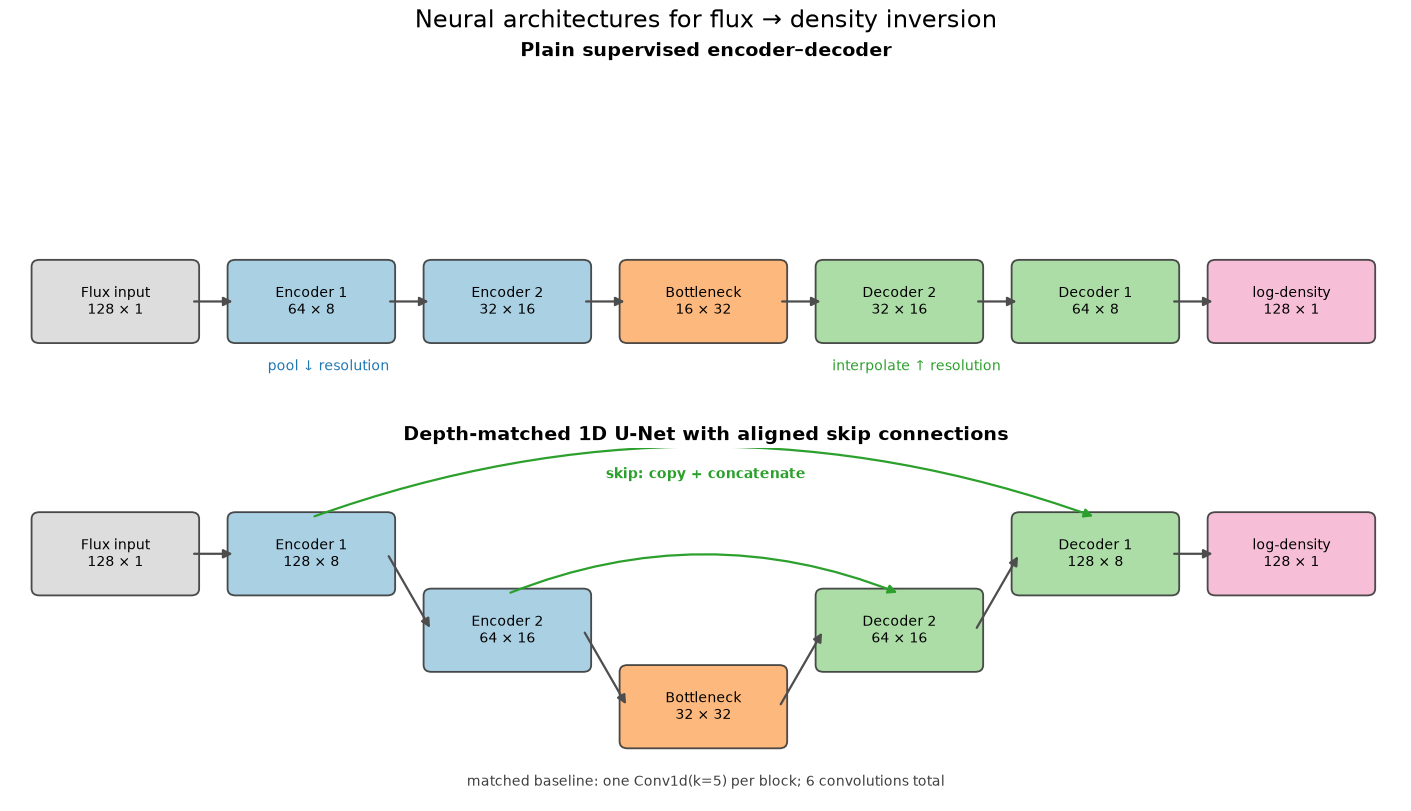

In [8]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

def architecture_block(ax, x0, y0, label, color, width=1.55, height=.82):
    patch = FancyBboxPatch(
        (x0, y0), width, height, boxstyle="round,pad=0.08",
        facecolor=color, edgecolor=".2", linewidth=1.3, alpha=.88,
    )
    ax.add_patch(patch)
    ax.text(x0+width/2, y0+height/2, label, ha="center", va="center", fontsize=10)
    return (x0, y0, width, height)

def architecture_arrow(ax, start, end, color=".3", connection="arc3"):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=13, linewidth=1.6,
        color=color, connectionstyle=connection, shrinkA=2, shrinkB=2,
    ))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
colors_arch = {"input": "#d9d9d9", "encoder": "#9ecae1", "bottleneck": "#fdae6b", "decoder": "#a1d99b", "output": "#f7b6d2"}

# Plain encoder–decoder: every feature must cross the bottleneck.
plain_labels = [
    ("Flux input\n128 × 1", "input"), ("Encoder 1\n64 × 8", "encoder"),
    ("Encoder 2\n32 × 16", "encoder"), ("Bottleneck\n16 × 32", "bottleneck"),
    ("Decoder 2\n32 × 16", "decoder"), ("Decoder 1\n64 × 8", "decoder"),
    ("log-density\n128 × 1", "output"),
]
plain_x = np.linspace(.2, 12.2, len(plain_labels))
for x0, (label, role) in zip(plain_x, plain_labels):
    architecture_block(axes[0], x0, 1.45, label, colors_arch[role])
for left, right in zip(plain_x[:-1], plain_x[1:]):
    architecture_arrow(axes[0], (left+1.55, 1.86), (right, 1.86))
axes[0].text(3.15, 1.05, "pool ↓ resolution", ha="center", color="tab:blue")
axes[0].text(9.15, 1.05, "interpolate ↑ resolution", ha="center", color="tab:green")
axes[0].set_title("Plain supervised encoder–decoder", fontsize=14, weight="bold")

# U-Net: solid arrows are the main path; curved green arrows are skip connections.
unet_nodes = [
    (.2, 3.0, "Flux input\n128 × 1", "input"),
    (2.2, 3.0, "Encoder 1\n128 × 8", "encoder"),
    (4.2, 2.1, "Encoder 2\n64 × 16", "encoder"),
    (6.2, 1.2, "Bottleneck\n32 × 32", "bottleneck"),
    (8.2, 2.1, "Decoder 2\n64 × 16", "decoder"),
    (10.2, 3.0, "Decoder 1\n128 × 8", "decoder"),
    (12.2, 3.0, "log-density\n128 × 1", "output"),
]
for x0, y0, label, role in unet_nodes:
    architecture_block(axes[1], x0, y0, label, colors_arch[role])
for (x0, y0, *_), (x1, y1, *_) in zip(unet_nodes[:-1], unet_nodes[1:]):
    architecture_arrow(axes[1], (x0+1.55, y0+.41), (x1, y1+.41))
architecture_arrow(axes[1], (2.98, 3.84), (10.98, 3.84), color="tab:green", connection="arc3,rad=-.18")
architecture_arrow(axes[1], (4.98, 2.94), (8.98, 2.94), color="tab:green", connection="arc3,rad=-.20")
axes[1].text(7.0, 4.3, "skip: copy + concatenate", ha="center", color="tab:green", weight="bold")
axes[1].text(7.0, .68, "matched baseline: one Conv1d(k=5) per block; 6 convolutions total", ha="center", color=".25")
axes[1].set_title("Depth-matched 1D U-Net with aligned skip connections", fontsize=14, weight="bold")

for ax in axes:
    ax.set(xlim=(-.1, 14.1), ylim=(.5, 4.65))
    ax.axis("off")
fig.suptitle("Neural architectures for flux → density inversion", fontsize=17)
fig.savefig(output_directory/"NN_architecture_schematic.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Train the U-Net

The depth-matched U-Net uses base channel count 8, kernel size 5, and the same training budget as the encoder–decoder. The final box-0 test skewer remains untouched during training and validation.

U-Net: base=8, levels=2, kernel=5


epoch  1/50: train=0.7462, validation=0.5263


epoch  5/50: train=0.4831, validation=0.4824


epoch 10/50: train=0.4760, validation=0.4754


epoch 15/50: train=0.4748, validation=0.4737


...

epoch 30/50: train=0.4716, validation=0.4743


epoch 35/50: train=0.4707, validation=0.4720


epoch 40/50: train=0.4703, validation=0.4717


epoch 45/50: train=0.4699, validation=0.4730


epoch 50/50: train=0.4697, validation=0.4725
kept best validation model; CPU time=37.2 s
best validation MSE: 0.47172


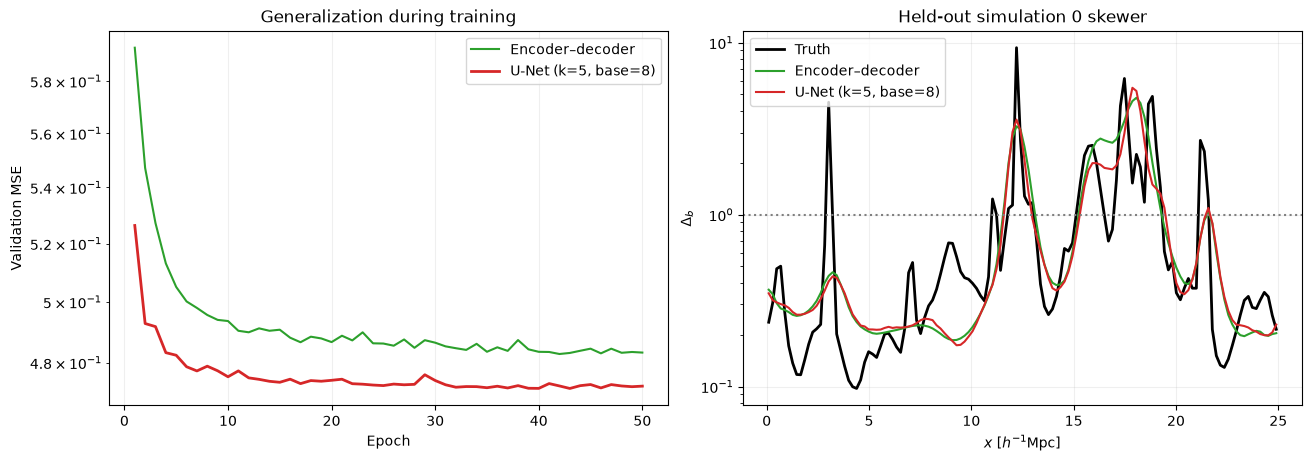

In [9]:
_, _, unet_train_loader, unet_val_loader = make_loaders(
    target_train, target_val, target_mean, target_std, seed=29
)
print("U-Net: base=8, levels=2, kernel=5")
history_unet = train_model(
    unet, unet_train_loader, unet_val_loader, train_set, val_set
)
print(f"best validation MSE: {min(history_unet['validation']):.5f}")


def predict_density(model, flux_1d, output_mean, output_std):
    xnet = torch.tensor(((flux_1d-flux_mean)/flux_std)[None, None, :], dtype=torch.float32, device=device)
    model.eval()
    with torch.no_grad():
        standardized = model(xnet).cpu().numpy()[0, 0]
    return np.clip(np.exp(output_mean + output_std*standardized), *density_limits)

Delta_b_auto = predict_density(autoencoder, test_flux, target_mean, target_std)
Delta_b_unet = predict_density(unet, test_flux, target_mean, target_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
epochs = np.arange(1, len(history_auto["train"])+1)
axes[0].semilogy(epochs, history_auto["validation"], label="Encoder–decoder", color="tab:green")
axes[0].semilogy(epochs, history_unet["validation"], label="U-Net (k=5, base=8)", color="tab:red", lw=2)
axes[0].set(xlabel="Epoch", ylabel="Validation MSE", title="Generalization during training")
axes[0].legend(); axes[0].grid(alpha=.2)

axes[1].semilogy(x, Delta_b_true, color="black", lw=2, label="Truth")
axes[1].semilogy(x, Delta_b_auto, color="tab:green", label="Encoder–decoder")
axes[1].semilogy(x, Delta_b_unet, color="tab:red", label="U-Net (k=5, base=8)")
axes[1].axhline(1, color=".5", ls=":")
axes[1].set(xlabel=r"$x\ [h^{-1}{\rm Mpc}]$", ylabel=r"$\Delta_b$", title="Held-out simulation 0 skewer")
axes[1].legend(); axes[1].grid(alpha=.2)
fig.savefig(output_directory/"NN_encoder_decoder_vs_unet.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Traditional baselines on the identical held-out flux

Direct FGPA and MAP receive only the held-out flux, instrument/noise settings, and the assumed $T_0$–$\gamma$ relation declared in the first cell. They never receive the hidden CAMELS test temperature. Direct FGPA ignores instrumental mixing; MAP forward-models the instrument and penalizes curvature in \(s=\ln\Delta_b\). Its regularization strength is selected without density truth by choosing data \(\chi^2/N\) closest to one.

In [10]:
# Direct FGPA
clipped_flux = np.clip(test_flux, noise_sigma, 1-1e-8)
Delta_b_direct = (-np.log(clipped_flux)/(A_fgpa*inversion_temperature_normalization))**(1.0/inversion_beta)

# Regularized MAP
L = np.zeros((N-2, N))
for row in range(N-2):
    L[row, row:row+3] = [1, -2, 1]

def forward_parts(s):
    tau = A_fgpa*inversion_temperature_normalization*np.exp(inversion_beta*s)
    intrinsic = np.exp(-tau)
    derivative = -inversion_beta*tau*intrinsic
    return K@intrinsic, K*derivative[None, :]

def residual(s, lam):
    model, _ = forward_parts(s)
    return np.concatenate([(model-test_flux)/noise_sigma, np.sqrt(lam)*(L@s)])

def jacobian(s, lam):
    _, jac = forward_parts(s)
    return np.vstack([jac/noise_sigma, np.sqrt(lam)*L])

initial = np.log(np.clip(ndimage.gaussian_filter1d(Delta_b_direct, 1, mode="reflect"), *density_limits))
bounds = (np.full(N, np.log(density_limits[0])), np.full(N, np.log(density_limits[1])))
lambda_grid = np.array([1000., 100., 10., 1., .1, .01])
solutions, chi2 = {}, {}
start = initial
for lam in lambda_grid:
    result = least_squares(residual, start, jac=jacobian, args=(lam,), bounds=bounds, max_nfev=100)
    solutions[lam] = result.x
    model, _ = forward_parts(result.x)
    chi2[lam] = np.mean(((model-test_flux)/noise_sigma)**2)
    start = result.x
selected_lambda = min(lambda_grid, key=lambda lam: abs(chi2[lam]-1))
Delta_b_map = np.exp(solutions[selected_lambda])
for lam in lambda_grid:
    print(f"lambda={lam:7g}, chi2/N={chi2[lam]:.3f}" + ("  <-- selected" if lam == selected_lambda else ""))

lambda=   1000, chi2/N=1.074
lambda=    100, chi2/N=0.943  <-- selected
lambda=     10, chi2/N=0.872
lambda=      1, chi2/N=0.832
lambda=    0.1, chi2/N=0.809
lambda=   0.01, chi2/N=0.799


## 10. Quantitative comparison

RMSE emphasizes peaks, MAE is more robust, log-RMSE measures multiplicative error across voids and peaks, and correlation tests spatial alignment. The 1D power spectrum checks recovered structure by scale.

Method                   RMSE      MAE   log-RMSE        r
Direct FGPA             1.144    0.596      1.464    0.501
Regularized MAP         1.076    0.510      1.041    0.635
Encoder-decoder         1.023    0.514      0.657    0.643
U-Net                   1.033    0.497      0.654    0.624


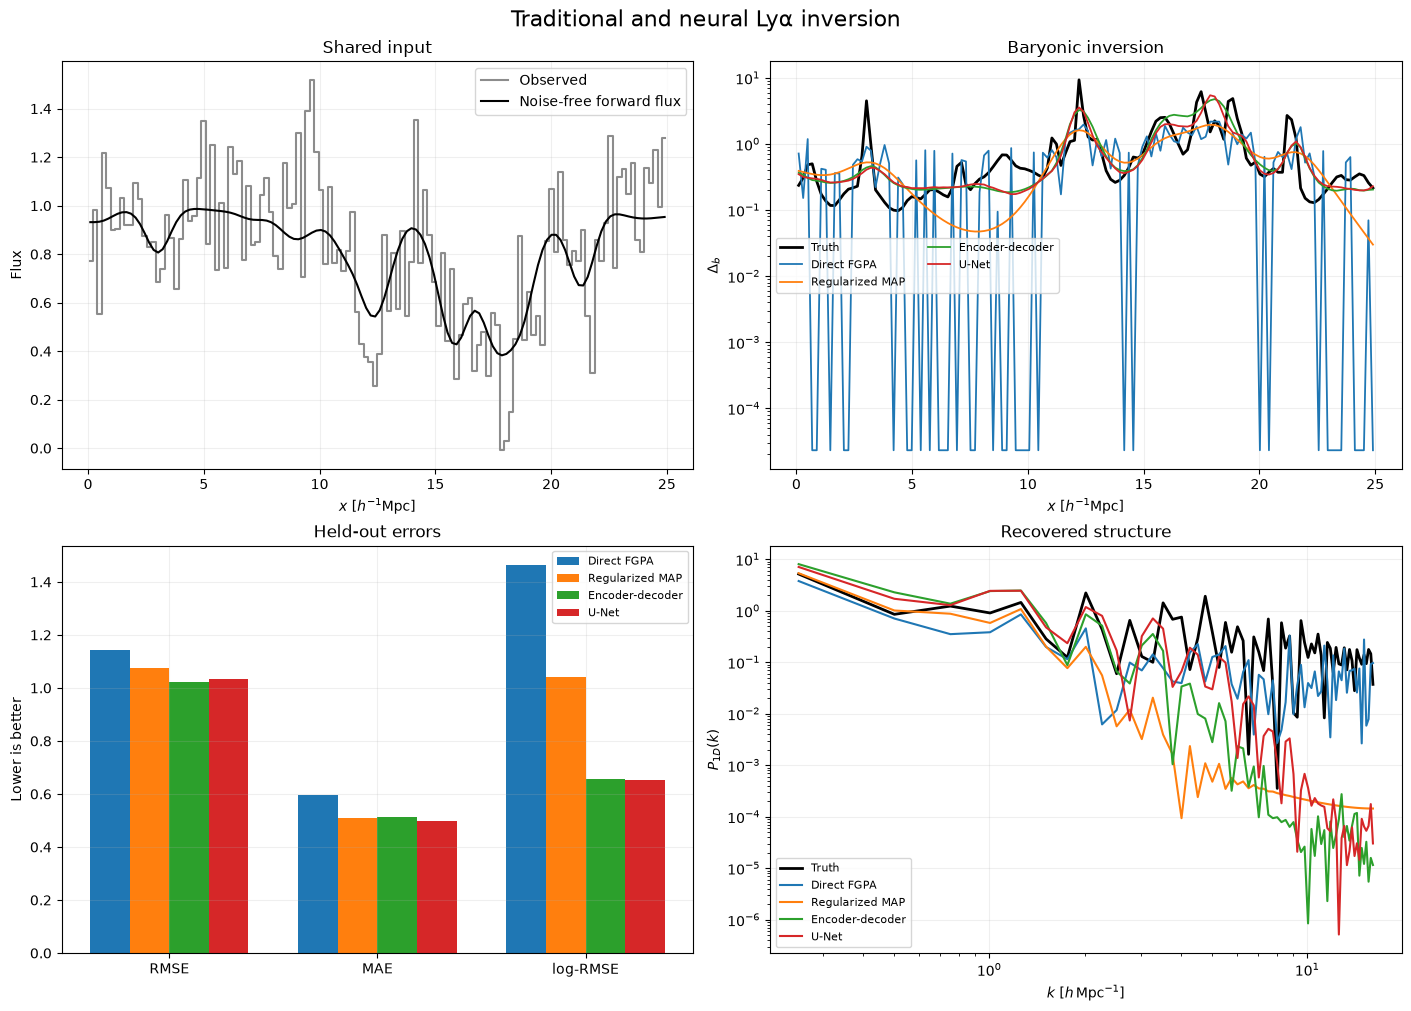

In [11]:
def metrics(truth, prediction):
    t, p = np.clip(truth, *density_limits), np.clip(prediction, *density_limits)
    return {
        "RMSE": np.sqrt(np.mean((p-t)**2)),
        "MAE": np.mean(np.abs(p-t)),
        "log-RMSE": np.sqrt(np.mean((np.log(p)-np.log(t))**2)),
        "r": np.corrcoef(t, p)[0, 1],
    }

predictions = {
    "Direct FGPA": Delta_b_direct,
    "Regularized MAP": Delta_b_map,
    "Encoder-decoder": Delta_b_auto,
    "U-Net": Delta_b_unet,
}
scores = {name: metrics(Delta_b_true, pred) for name, pred in predictions.items()}
print(f"{'Method':20s} {'RMSE':>8s} {'MAE':>8s} {'log-RMSE':>10s} {'r':>8s}")
for name, score in scores.items():
    print(f"{name:20s} {score['RMSE']:8.3f} {score['MAE']:8.3f} {score['log-RMSE']:10.3f} {score['r']:8.3f}")

def power_1d(density):
    contrast = density/density.mean()-1
    ft = dx*np.fft.rfft(contrast)
    k = 2*np.pi*np.fft.rfftfreq(N, d=dx)
    return k[1:], (np.abs(ft)**2/(N*dx))[1:]

colors = {"Direct FGPA":"tab:blue", "Regularized MAP":"tab:orange", "Encoder-decoder":"tab:green", "U-Net":"tab:red"}
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes[0,0].step(x, test_flux, where="mid", color=".55", label="Observed")
axes[0,0].plot(x, test_flux_clean, color="black", label="Noise-free forward flux")
axes[0,0].set(title="Shared input", xlabel=r"$x\ [h^{-1}{\rm Mpc}]$", ylabel="Flux"); axes[0,0].legend()

axes[0,1].semilogy(x, Delta_b_true, color="black", lw=2, label="Truth")
for name, pred in predictions.items():
    axes[0,1].semilogy(x, pred, color=colors[name], lw=1.3, label=name)
axes[0,1].set(title="Baryonic inversion", xlabel=r"$x\ [h^{-1}{\rm Mpc}]$", ylabel=r"$\Delta_b$")
axes[0,1].legend(fontsize=8, ncol=2)

metric_names = ["RMSE", "MAE", "log-RMSE"]
pos, width = np.arange(3), .19
for offset, (name, score) in enumerate(scores.items()):
    axes[1,0].bar(pos+(offset-1.5)*width, [score[m] for m in metric_names], width, color=colors[name], label=name)
axes[1,0].set_xticks(pos, metric_names); axes[1,0].set(title="Held-out errors", ylabel="Lower is better")
axes[1,0].legend(fontsize=8)

k, ptrue = power_1d(Delta_b_true)
axes[1,1].loglog(k, ptrue, color="black", lw=2, label="Truth")
for name, pred in predictions.items():
    axes[1,1].loglog(k, power_1d(pred)[1], color=colors[name], label=name)
axes[1,1].set(title="Recovered structure", xlabel=r"$k\ [h\,{\rm Mpc}^{-1}]$", ylabel=r"$P_{1D}(k)$")
axes[1,1].legend(fontsize=8)
for ax in axes.flat: ax.grid(alpha=.2)
fig.suptitle("Traditional and neural Lyα inversion", fontsize=16)
fig.savefig(output_directory/"NN_vs_traditional_inversion.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Direct neural dark-matter inversion

Using a baryon reconstruction as a dark-matter estimate is only a proxy. Here we train two **new** networks with the same noisy flux inputs but replace the labels by the co-spatial standardized \(\ln\Delta_{\rm dm}\) skewers. The DM U-Net uses the same fixed base-8, kernel-5 architecture as the baryon U-Net. The 26-box training/validation coordinates and untouched box-0 test are identical to the baryon experiment, so the comparison isolates the effect of changing the supervised target. The traditional FGPA and MAP solutions remain baryon-based DM proxies because their forward model targets baryons rather than DM.

epoch  1/50: train=0.7634, validation=0.6123


epoch  5/50: train=0.5376, validation=0.5398


epoch 10/50: train=0.5228, validation=0.5276


epoch 15/50: train=0.5171, validation=0.5226


epoch 20/50: train=0.5139, validation=0.5206


...

epoch 30/50: train=0.5021, validation=0.5072


epoch 35/50: train=0.5019, validation=0.5075


epoch 40/50: train=0.5009, validation=0.5079


epoch 45/50: train=0.5007, validation=0.5076


epoch 50/50: train=0.5003, validation=0.5085
kept best validation model; CPU time=38.8 s
DM method                  RMSE      MAE   log-RMSE        r
Direct FGPA proxy         0.997    0.532      1.453    0.502
MAP baryon proxy          0.938    0.453      1.015    0.609
Baryon encoder proxy      0.962    0.468      0.662    0.632
Baryon U-Net proxy        0.945    0.459      0.657    0.621
Direct-DM encoder         0.885    0.414      0.638    0.652
Direct-DM U-Net           0.879    0.419      0.641    0.647


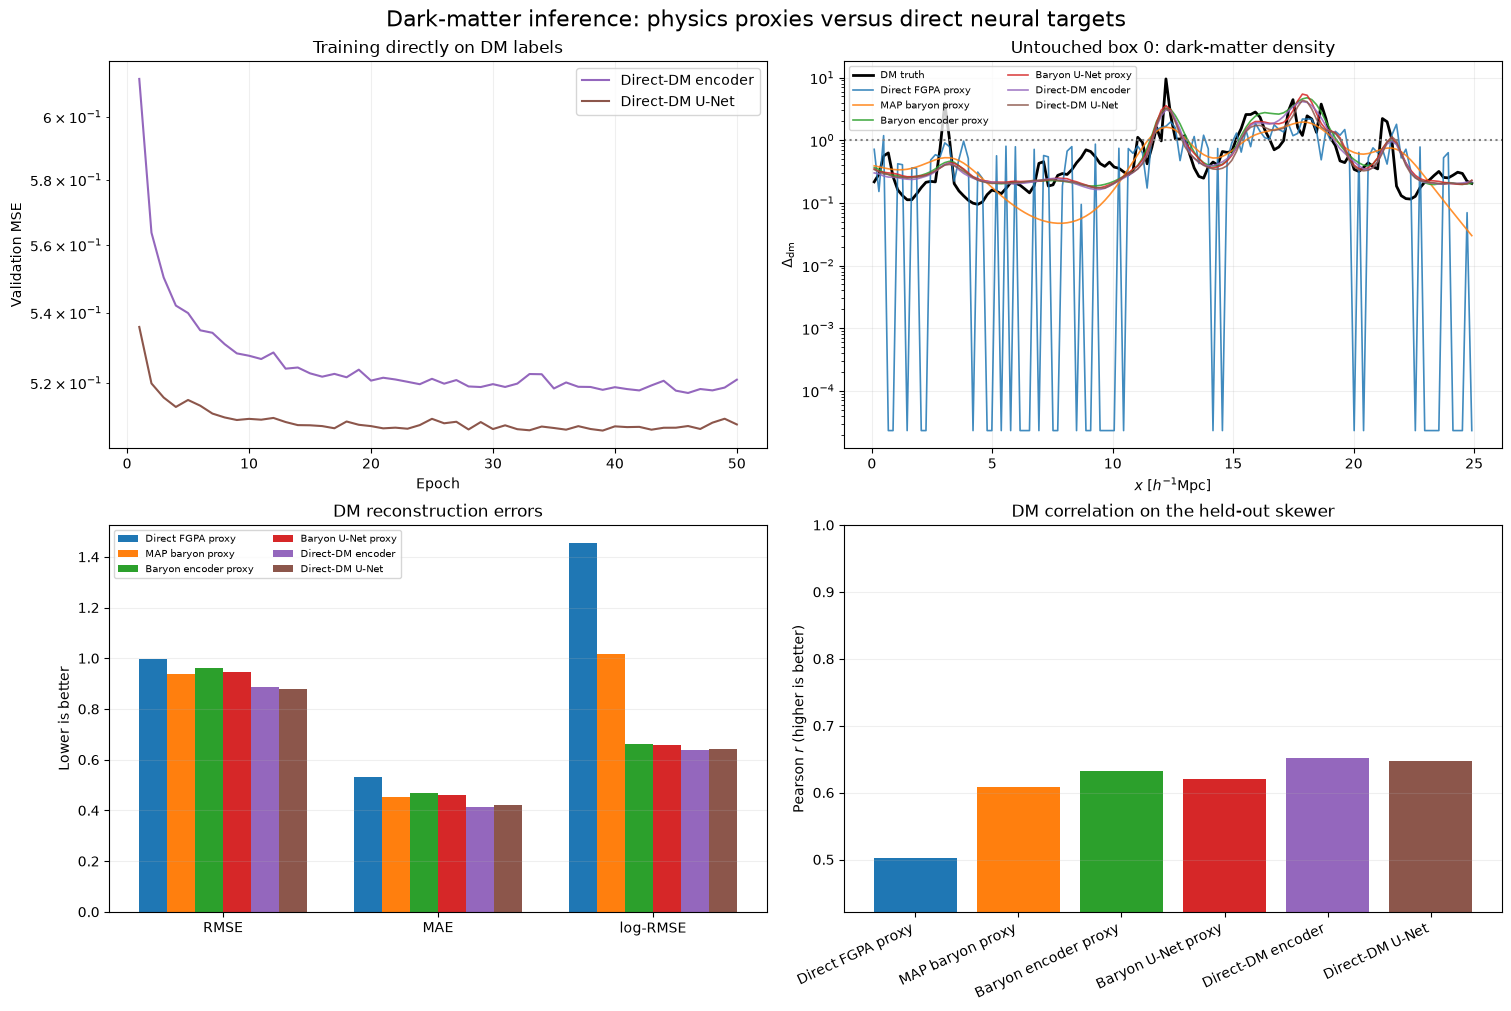

In [12]:
torch.manual_seed(17)
dm_autoencoder = PlainEncoderDecoder().to(device)
dm_unet = UNet1D(base_channels=8, levels=2, kernel_size=5).to(device)

history_dm_auto = train_model(
    dm_autoencoder, dm_train_loader, dm_val_loader, dm_train_set, dm_val_set
)
history_dm_unet = train_model(
    dm_unet, dm_train_loader, dm_val_loader, dm_train_set, dm_val_set
)

Delta_dm_auto = predict_density(dm_autoencoder, test_flux, dm_target_mean, dm_target_std)
Delta_dm_unet = predict_density(dm_unet, test_flux, dm_target_mean, dm_target_std)
dm_predictions = {
    "Direct FGPA proxy": Delta_b_direct,
    "MAP baryon proxy": Delta_b_map,
    "Baryon encoder proxy": Delta_b_auto,
    "Baryon U-Net proxy": Delta_b_unet,
    "Direct-DM encoder": Delta_dm_auto,
    "Direct-DM U-Net": Delta_dm_unet,
}
dm_scores = {name: metrics(Delta_dm_true, prediction) for name, prediction in dm_predictions.items()}
print(f"{'DM method':22s} {'RMSE':>8s} {'MAE':>8s} {'log-RMSE':>10s} {'r':>8s}")
for name, score in dm_scores.items():
    print(f"{name:22s} {score['RMSE']:8.3f} {score['MAE']:8.3f} {score['log-RMSE']:10.3f} {score['r']:8.3f}")

dm_colors = {
    "Direct FGPA proxy": "tab:blue", "MAP baryon proxy": "tab:orange",
    "Baryon encoder proxy": "tab:green", "Baryon U-Net proxy": "tab:red",
    "Direct-DM encoder": "tab:purple", "Direct-DM U-Net": "tab:brown",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
dm_epochs = np.arange(1, len(history_dm_auto["validation"])+1)
axes[0,0].semilogy(dm_epochs, history_dm_auto["validation"], color="tab:purple", label="Direct-DM encoder")
axes[0,0].semilogy(dm_epochs, history_dm_unet["validation"], color="tab:brown", label="Direct-DM U-Net")
axes[0,0].set(title="Training directly on DM labels", xlabel="Epoch", ylabel="Validation MSE")
axes[0,0].legend(); axes[0,0].grid(alpha=.2)

axes[0,1].semilogy(x, Delta_dm_true, color="black", lw=2, label="DM truth")
for name, prediction in dm_predictions.items():
    axes[0,1].semilogy(x, prediction, color=dm_colors[name], lw=1.2, alpha=.85, label=name)
axes[0,1].axhline(1, color=".5", ls=":")
axes[0,1].set(title="Untouched box 0: dark-matter density", xlabel=r"$x\ [h^{-1}{\rm Mpc}]$", ylabel=r"$\Delta_{\rm dm}$")
axes[0,1].legend(fontsize=7, ncol=2); axes[0,1].grid(alpha=.2)

dm_metric_names = ["RMSE", "MAE", "log-RMSE"]
dm_positions, dm_width = np.arange(len(dm_metric_names)), .13
for index, (name, score) in enumerate(dm_scores.items()):
    offset = (index-(len(dm_scores)-1)/2)*dm_width
    axes[1,0].bar(dm_positions+offset, [score[metric] for metric in dm_metric_names], dm_width, color=dm_colors[name], label=name)
axes[1,0].set_xticks(dm_positions, dm_metric_names)
axes[1,0].set(title="DM reconstruction errors", ylabel="Lower is better")
axes[1,0].legend(fontsize=7, ncol=2); axes[1,0].grid(axis="y", alpha=.2)

dm_names = list(dm_scores)
dm_correlations = [dm_scores[name]["r"] for name in dm_names]
axes[1,1].bar(np.arange(len(dm_names)), dm_correlations, color=[dm_colors[name] for name in dm_names])
axes[1,1].set_xticks(np.arange(len(dm_names)), dm_names, rotation=25, ha="right")
axes[1,1].set_ylim(max(0, min(dm_correlations)-.08), 1.0)
axes[1,1].set(title="DM correlation on the held-out skewer", ylabel=r"Pearson $r$ (higher is better)")
axes[1,1].grid(axis="y", alpha=.2)
fig.suptitle("Dark-matter inference: physics proxies versus direct neural targets", fontsize=16)
fig.savefig(output_directory/"NN_direct_dm_inversion.png", dpi=160, bbox_inches="tight")
plt.show()

### Why does a neural network not automatically win?

The compact base-8 U-Net is compared with MAP for both the **baryon** target and the direct **DM** target on the central held-out skewer. This one-skewer result is illustrative and is not evidence that a neural estimator is generally superior.

Several effects explain why a neural network is not guaranteed to rank first:

- **MAP has explicit observational physics.** It knows the FGPA normalization, instrumental kernel, noise variance, and an assumed $T_0$–$\gamma$ relation, then optimizes a fresh latent field for that skewer. It does not receive the hidden CAMELS temperature, so its thermal model is intentionally imperfect.
- **The network is an amortized estimator.** One fixed mapping must work for every skewer. With an MSE loss it tends toward a conditional mean, which suppresses rare sharp density peaks and can increase linear RMSE even when typical and logarithmic errors improve.
- **Training and model capacity are intentionally modest.** There are 3,328 training skewers, the U-Net base width is fixed at 8, and the learning rate and loss are not extensively tuned. More epochs or width alone cannot replace representative data and a loss aligned with the desired metric.
- **Flux does not uniquely determine DM.** Saturation, noise, instrumental smoothing, and baryon–DM differences remove information. A neural network cannot recover information absent from the input; it can only learn a simulation-dependent prior.
- **This ranking uses one central skewer from one held-out box.** A defensible method ranking requires an ensemble of unseen skewers, confidence intervals, and tests under changed noise and astrophysics.

Finally, direct FGPA and MAP are labeled *DM proxies* here because they reconstruct baryons and are only compared with DM afterward. The direct-DM networks are the only estimators in this section trained explicitly against DM labels.

## 12. Conclusions and student experiments

- The plain encoder–decoder is transparent and compact, but its bottleneck tends to smooth fine detail.
- U-Net skip connections combine coarse context with aligned high-resolution features; its kernel size is 5, its base channel count is 8, and its convolution count matches the plain encoder–decoder.
- The direct-DM networks learn from co-spatial DM labels; their predictions are genuine supervised DM estimates rather than relabeled baryon reconstructions.
- Direct FGPA is cheap and interpretable but ignores resolution mixing and amplifies noise.
- MAP exposes its likelihood and smoothness prior explicitly. A network is fast after training, but its prior is implicit in its simulations and training choices.
- All 26 development boxes contribute training data, while box 0 remains untouched until the final test. Validation uses disjoint skewers from the development boxes and therefore must not be confused with new-box generalization.
- This controlled demonstration trains and tests with the same FGPA, instrument, S/N, and simulation family. Real analyses must vary nuisance physics, resolution, noise, continuum errors, thermal broadening, peculiar velocities, and simulation model, and must estimate uncertainty.

Try changing S/N, halving the training set, removing the U-Net concatenations, or doubling channels. Compare accuracy, validation behavior, CPU time, and high-\(k\) power. Training at one noise level and testing at another is a particularly useful demonstration of distribution shift.